# Handwritten Digit Recognition with CNN

This notebook trains a Convolutional Neural Network (CNN) to recognize handwritten digits (0–9) using TensorFlow/Keras.

## Phase 1 — Environment Setup

In [20]:
!pip install numpy pandas matplotlib pillow scikit-learn tensorflow seaborn

Defaulting to user installation because normal site-packages is not writeable


In [21]:
import os
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("All packages imported successfully!")
print("TensorFlow version:", tf.__version__)

All packages imported successfully!
TensorFlow version: 2.21.0


## Phase 2 — Dataset Preparation

In [22]:
print("Current working directory:")
print(os.getcwd())

print("\nFiles and folders:")
for item in os.listdir():
    print(item)

Current working directory:
C:\Users\ISUG\Desktop\DA

Files and folders:
.freebuff
.ipynb_checkpoints
DA
DA.zip
digit.ipynb
digit_clean.ipynb
digit_recognition.ipynb
handwritten_digit_cnn.keras
test_digit.jpg


In [23]:
# Extract the dataset
zip_path = "DA.zip"
extract_path = "DA"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [24]:
# List digit classes
dataset_path = "DA"

digits = sorted([
    folder for folder in os.listdir(dataset_path)
    if os.path.isdir(os.path.join(dataset_path, folder))
])

print("Classes:", digits)
print("Number of classes:", len(digits))

Classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
Number of classes: 10


### Count images per class

In [25]:
class_counts = {}

for digit in sorted(os.listdir(dataset_path)):
    folder_path = os.path.join(dataset_path, digit)

    if os.path.isdir(folder_path):
        image_files = [
            file for file in os.listdir(folder_path)
            if file.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".gif"))
        ]
        class_counts[digit] = len(image_files)
        print(f"Digit {digit}: {len(image_files)} images")

print(f"\nTotal images: {sum(class_counts.values())}")

Digit 0: 152 images
Digit 1: 113 images
Digit 2: 142 images
Digit 3: 119 images
Digit 4: 143 images
Digit 5: 142 images
Digit 6: 133 images
Digit 7: 116 images
Digit 8: 116 images
Digit 9: 113 images

Total images: 1289


### Visualize class distribution

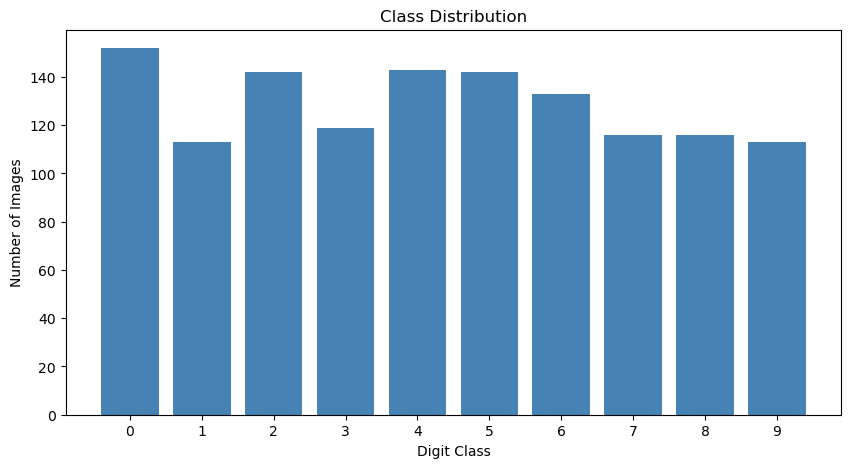

In [26]:
plt.figure(figsize=(10, 5))
plt.bar(class_counts.keys(), class_counts.values(), color="steelblue")
plt.xlabel("Digit Class")
plt.ylabel("Number of Images")
plt.title("Class Distribution")
plt.xticks(list(class_counts.keys()))
plt.show()

### Load and preprocess images

In [27]:
IMG_SIZE = 64

images = []
labels = []

for digit in digits:
    folder_path = os.path.join(dataset_path, digit)
    if not os.path.isdir(folder_path):
        continue
    for file in os.listdir(folder_path):
        file_path = os.path.join(folder_path, file)
        if file.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".gif")):
            img = Image.open(file_path).convert("L")  # grayscale
            img = img.resize((IMG_SIZE, IMG_SIZE))
            images.append(np.array(img))
            labels.append(int(digit))

images = np.array(images)
labels = np.array(labels)

# Normalize to [0, 1]
images = images / 255.0

# Add channel dimension for CNN: (N, H, W, 1)
images = np.expand_dims(images, axis=-1)

print(f"Images shape: {images.shape}")
print(f"Labels shape: {labels.shape}")

Images shape: (1289, 64, 64, 1)
Labels shape: (1289,)


### Show sample images

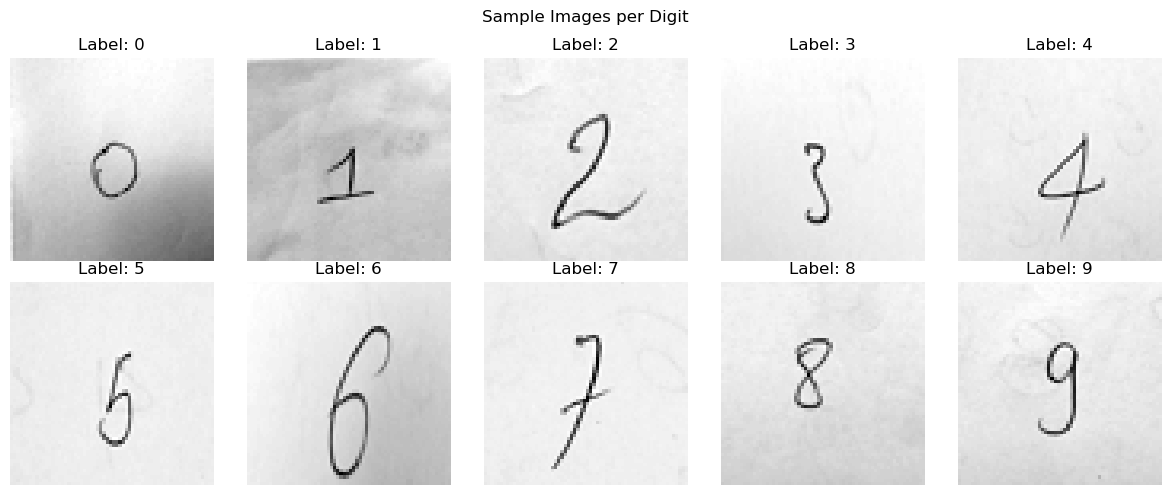

In [28]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    idx = np.where(labels == i)[0][0]
    ax.imshow(images[idx].squeeze(), cmap="gray")
    ax.set_title(f"Label: {i}")
    ax.axis("off")
plt.suptitle("Sample Images per Digit")
plt.tight_layout()
plt.show()

### Train/test split

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    images, labels, test_size=0.2, random_state=42, stratify=labels
)

print(f"Training set: {X_train.shape[0]} images")
print(f"Test set:     {X_test.shape[0]} images")

Training set: 1031 images
Test set:     258 images


## Phase 3 — Build the CNN Model

In [30]:
model = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation="relu", input_shape=(IMG_SIZE, IMG_SIZE, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(10, activation="softmax"),
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

model.summary()

C:\Users\ISUG\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 62, 62, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 683,914 (2.61 MB)

 Trainable params: 683,914 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

## Phase 4 — Train the Model

In [31]:
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.15,
)

Epoch 1/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.1005 - loss: 2.3131 - val_accuracy: 0.0968 - val_loss: 2.3047
Epoch 2/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.1233 - loss: 2.2989 - val_accuracy: 0.0968 - val_loss: 2.2948
Epoch 3/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.1301 - loss: 2.2731 - val_accuracy: 0.1742 - val_loss: 2.2253
Epoch 4/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.1632 - loss: 2.2134 - val_accuracy: 0.1742 - val_loss: 2.1870
Epoch 5/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.1872 - loss: 2.1845 - val_accuracy: 0.1548 - val_loss: 2.1992
Epoch 6/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.1975 - loss: 2.1243 - val_accuracy: 0.2516 - val_loss: 2.1190
Epoch 7/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.2568 - loss: 2.0647 - val_accuracy: 0.2839 - val_loss: 2.0309
Epoch 8/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.2785 - loss: 1.9652 - val_accuracy: 0.3355 - v

### Plot training history

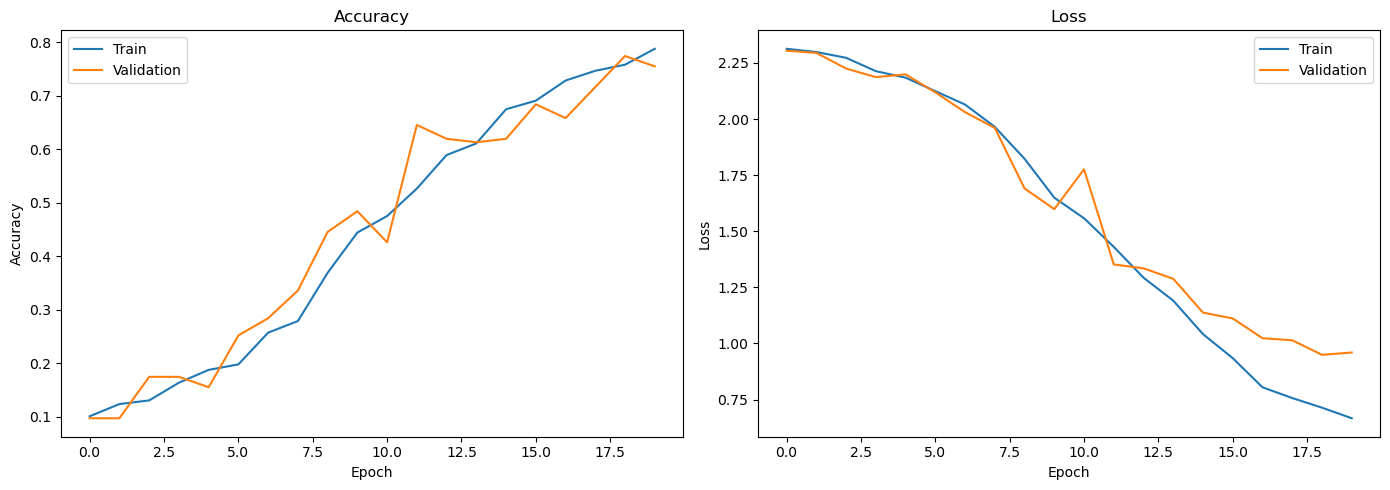

In [32]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history["accuracy"], label="Train")
ax1.plot(history.history["val_accuracy"], label="Validation")
ax1.set_title("Accuracy")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy")
ax1.legend()

ax2.plot(history.history["loss"], label="Train")
ax2.plot(history.history["val_loss"], label="Validation")
ax2.set_title("Loss")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Loss")
ax2.legend()

plt.tight_layout()
plt.show()

## Phase 5 — Evaluate the Model

In [33]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss:     {test_loss:.4f}")

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7519 - loss: 0.9550
Test Accuracy: 0.7519
Test Loss:     0.9550


In [34]:
y_pred = np.argmax(model.predict(X_test), axis=1)

print("Classification Report:")
print(classification_report(y_test, y_pred))

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.90      0.90        30
           1       0.74      0.87      0.80        23
           2       0.66      0.75      0.70        28
           3       0.73      0.67      0.70        24
           4       0.76      0.76      0.76        29
           5       0.90      0.68      0.78        28
           6       0.80      0.74      0.77        27
           7       0.68      0.83      0.75        23
           8       0.68      0.74      0.71        23
           9       0.68      0.57      0.62        23

    accuracy                           0.75       258
   macro avg       0.75      0.75      0.75       258
weighted avg       0.76      0.75      0.75       258



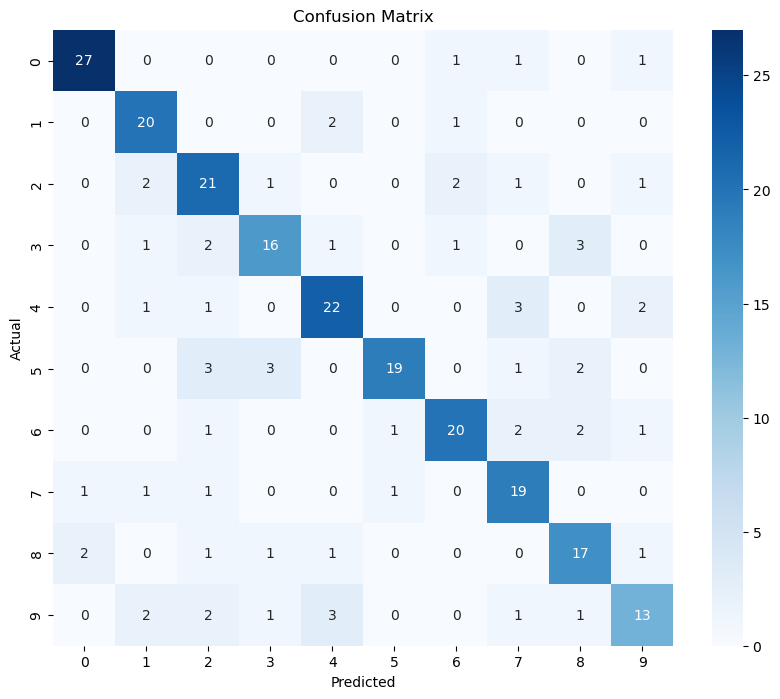

In [35]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=digits, yticklabels=digits)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## Phase 6 — Predict on New Image

In [36]:
def predict_digit(image_path):
    img = Image.open(image_path).convert("L")
    img = img.resize((IMG_SIZE, IMG_SIZE))
    img_array = np.array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=(0, -1))

    prediction = model.predict(img_array)
    predicted_digit = np.argmax(prediction)
    confidence = np.max(prediction)

    plt.imshow(img, cmap="gray")
    plt.title(f"Predicted: {predicted_digit} (confidence: {confidence:.2%})")
    plt.axis("off")
    plt.show()

    return predicted_digit, confidence

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


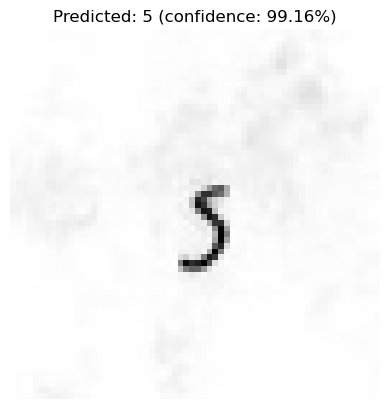

(np.int64(5), np.float32(0.9915985))

In [37]:
predict_digit("test_digit.jpg")

## Phase 7 — Save the Model

In [38]:
model.save("handwritten_digit_cnn.keras")
print("Model saved successfully!")

Model saved successfully!
